# Student Performance Grouping - Hierarchical Clustering

### Introduction

Every classroom has students who study very little and still do fine, some who study a lot and score
high, and everyone in between. In this project, we don't tell the computer what "high performer" or
"low performer" means — instead, we give it just two numbers for each student (hours studied and the
score they got), and let **hierarchical clustering** figure out the natural groups on its own.

We'll build a dendrogram (a tree showing how students get grouped step by step), decide how many groups
actually make sense using the silhouette score, and finally label each group in plain terms like
"Low Performers", "Average Performers", and "High Performers".

By the end, we'll have a simple, visual, easy-to-explain grouping of students based purely on their
study habits and results — no guessing, backed by the data.

## Importing tools & Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

plt.rcParams['figure.figsize'] = (8, 5)
print("Libraries loaded.")

Libraries loaded.


## Loading dataset

Our dataset has just two columns — `Hours` (hours studied) and `Scores` (marks obtained). Simple and
clean, which is exactly what we want while learning.

In [2]:
df = pd.read_csv("score_updated.csv")

In [3]:
print("Shape of dataset:", df.shape)

Shape of dataset: (96, 2)


In [4]:
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


### Data check

In [5]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Hours     0
Scores    0
dtype: int64


In [6]:
print("\nBasic statistics:")
df.describe()


Basic statistics:


,Hours,Scores
count,96.000000,96.000000
mean,5.267708,54.020833
std,2.503030,25.017459
min,1.000000,12.000000
25%,3.075000,30.750000
50%,5.250000,54.500000
75%,7.325000,74.250000
max,9.800000,99.000000


## Data visualization

Before running any algorithm, let's just plot Hours vs Scores and see if we can spot natural groups with
our own eyes. This helps us sanity-check whatever the algorithm gives us later.

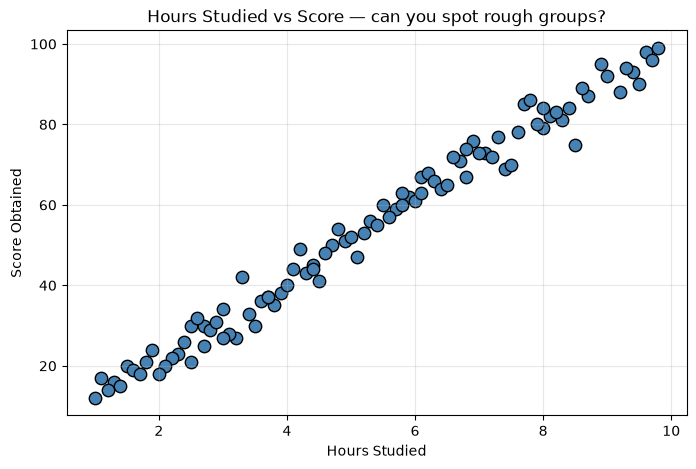

In [7]:
plt.scatter(df['Hours'], df['Scores'], s=80, c='steelblue', edgecolor='black')
plt.xlabel("Hours Studied")
plt.ylabel("Score Obtained")
plt.title("Hours Studied vs Score — can you spot rough groups?")
plt.grid(alpha=0.3)
plt.show()

### Feature Scaling

`Hours` ranges roughly 1–9, while `Scores` ranges roughly 12–99. If we don't scale them, the clustering
algorithm will think `Scores` matters much more than `Hours`, simply because its numbers are bigger - not
because it's actually more important. Scaling puts both columns on the same footing before we measure
distances between students.

In [8]:
X = df[['Hours', 'Scores']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling (first 5 rows):\n", X[:5])
print("\nAfter scaling (first 5 rows):\n", np.round(X_scaled[:5], 2))

Before scaling (first 5 rows):
 [[ 2.5 21. ]
 [ 5.1 47. ]
 [ 3.2 27. ]
 [ 8.5 75. ]
 [ 3.5 30. ]]

After scaling (first 5 rows):
 [[-1.11 -1.33]
 [-0.07 -0.28]
 [-0.83 -1.09]
 [ 1.3   0.84]
 [-0.71 -0.97]]


## Dendrogram

Think of this like a speed-dating merge: every student starts alone, and at each step the two closest
students (or groups of students) are merged. This continues until everyone is merged into one giant
group. The result is a tree called a **dendrogram**.

- Each vertical line joining two branches = a merge.
- The height of that join = how different the two merging groups were.
- Low joins = students who were very similar (obvious group). High joins = forcing together groups that
  weren't that alike.

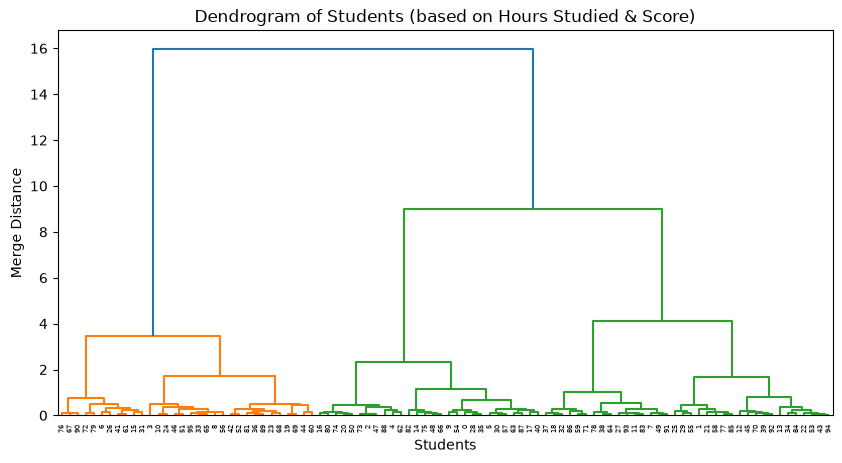

In [9]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title("Dendrogram of Students (based on Hours Studied & Score)")
plt.xlabel("Students")
plt.ylabel("Merge Distance")
plt.show()

## Silhouette Score

Looking at a dendrogram, we could guess the number of groups — but let's back that guess with a number.
The **silhouette score** checks, for every student, whether they fit better in their own group or would
actually fit better in a neighboring group. A higher score means tighter, better-separated groups.

We'll try a few different values of K (number of groups) and see which one scores best.

K=2 -> silhouette score = 0.54666
K=3 -> silhouette score = 0.54738
K=4 -> silhouette score = 0.49609
K=5 -> silhouette score = 0.51703
K=6 -> silhouette score = 0.46919


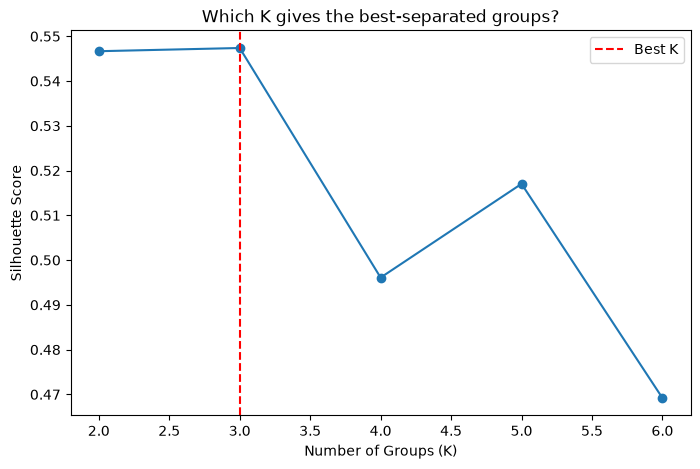


Best K according to silhouette score: 3


In [10]:
K_range = range(2, 7)
scores = []

for k in K_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"K={k} -> silhouette score = {score:.5f}")

plt.plot(list(K_range), scores, marker='o')
plt.xlabel("Number of Groups (K)")
plt.ylabel("Silhouette Score")
plt.title("Which K gives the best-separated groups?")
plt.axvline(x=list(K_range)[np.argmax(scores)], color='red', linestyle='--', label='Best K')
plt.legend()
plt.show()

best_k = list(K_range)[np.argmax(scores)]
print(f"\nBest K according to silhouette score: {best_k}")

## Grouping students using the best K

Now we cut the dendrogram at the height that gives us `best_k` groups, and actually assign every student
to a group.

In [11]:
final_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['Cluster'] = final_model.fit_predict(X_scaled)

df.head(10)

,Hours,Scores,Cluster
0,2.5,21,2
1,5.1,47,0
2,3.2,27,2
3,8.5,75,1
4,3.5,30,2
5,1.5,20,2
6,9.2,88,1
7,5.5,60,0
8,8.3,81,1
9,2.7,25,2


### Group Visualization

Let's color each student by their assigned group and see how it lines up with what we guessed by eye
back in Step 3.

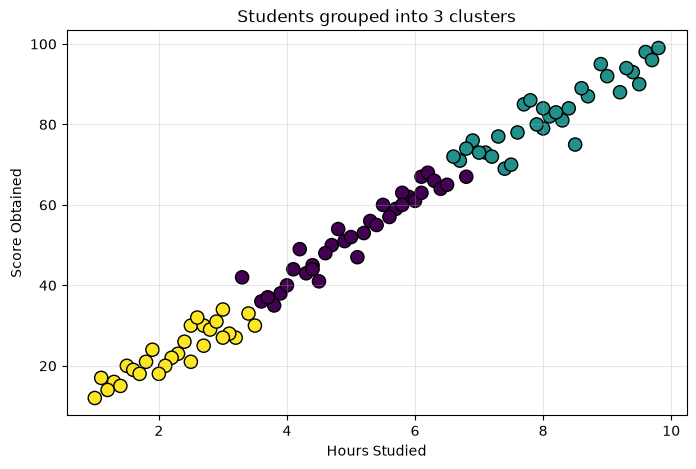

In [12]:
plt.scatter(df['Hours'], df['Scores'], c=df['Cluster'], cmap='viridis', s=90, edgecolor='black')
plt.xlabel("Hours Studied")
plt.ylabel("Score Obtained")
plt.title(f"Students grouped into {best_k} clusters")
plt.grid(alpha=0.3)
plt.show()

## Giving the groups real, human-readable names

Cluster numbers like `0`, `1`, `2` don't mean anything on their own. Let's check the average score in
each cluster and rename them in plain terms  this is the step that turns "clustering output" into an
actual insight someone can use.

In [13]:
cluster_summary = df.groupby('Cluster')[['Hours', 'Scores']].mean().sort_values('Scores')
print("Average Hours & Score per cluster (sorted low to high):")
print(cluster_summary)

# Rank clusters by average score and assign readable labels
ordered_clusters = cluster_summary.index.tolist()
label_names = ['Low Performers', 'Average Performers', 'High Performers', 'Top Performers', 'Extra Group']
label_map = {cluster_id: label_names[i] for i, cluster_id in enumerate(ordered_clusters)}

df['Performance Group'] = df['Cluster'].map(label_map)
df[['Hours', 'Scores', 'Performance Group']].head(10)

Average Hours & Score per cluster (sorted low to high):
            Hours     Scores
Cluster                     
2        2.264286  23.642857
0        5.044444  52.194444
1        8.146875  82.656250


,Hours,Scores,Performance Group
0,2.5,21,Low Performers
1,5.1,47,Average Performers
2,3.2,27,Low Performers
3,8.5,75,High Performers
4,3.5,30,Low Performers
5,1.5,20,Low Performers
6,9.2,88,High Performers
7,5.5,60,Average Performers
8,8.3,81,High Performers
9,2.7,25,Low Performers


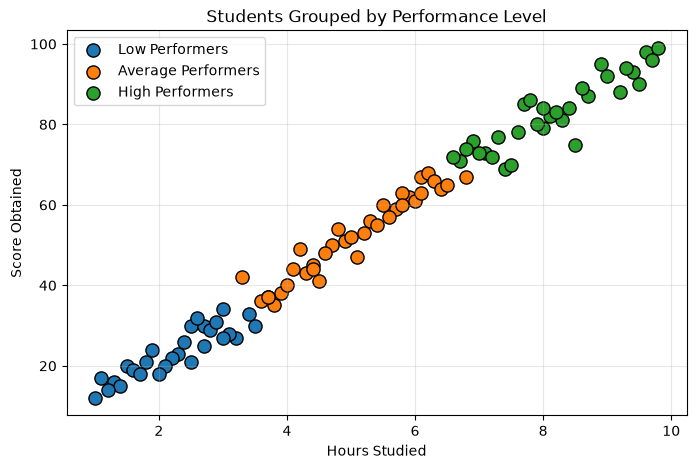

In [14]:
plt.figure(figsize=(8, 5))
for cluster_id, group_name in label_map.items():
    subset = df[df['Cluster'] == cluster_id]
    plt.scatter(subset['Hours'], subset['Scores'], s=90, edgecolor='black', label=group_name)

plt.xlabel("Hours Studied")
plt.ylabel("Score Obtained")
plt.title("Students Grouped by Performance Level")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Conclusion

We started with nothing but two simple numbers per student - hours studied and the score they got - and
let hierarchical clustering find natural groupings on its own, without ever telling it what "good" or
"bad" performance means.

The dendrogram showed us how students merge together step by step, and the silhouette score gave us a
data-backed answer for how many groups actually make sense, instead of just guessing. Once we labeled
those groups in plain terms, the result matched common sense: students who study less tend to land in the
lower-scoring group, and students who put in more hours tend to land in the higher-scoring group — but
now we have it grouped and labeled cleanly, backed by numbers rather than gut feeling.

This is really the core value of clustering: turning a messy scatter of individual data points into a
small number of meaningful, explainable groups.